## Лабораторная работа 6 **(18 баллов)**

---

### №1 **(2 балла)**

---

### Полиномиальная регрессия. Как из линейной регрессии сделать криволинейную?

Линейная модель (прямая линия):
![img](http://neerc.ifmo.ru/wiki/images/f/f0/Linear_regression_example.png)

***А что если нельзя провести оптимальную прямую линию?***
<a href="https://ibb.co/XXBwvBP"><img src="https://i.ibb.co/Wn9TY9X/9.jpg" alt="9" border="0"></a>

Нужно использовать нелинейную модель:
![img](https://www.machinelearningmastery.ru/img/0-399364-636329.png)

***Модель полиномиальной регрессии (polynomial regression)*** - это обобщенная линейная модель с параметризованной степенью многочлена.

![img](https://russianblogs.com/images/753/361716febc5a15ae65cdba4394db1f69.png)

Многочлен 1-й степени:

$$ y=ax+b $$ 

Многочлен 3-й степени:
$$ y = ax^3 + bx^2 + cx + d $$

Несмотря на то, что мы можем использовать полиномиальную регрессию для моделирования нелинейных связей, она по-прежнему рассматривается как модель множественной линейной регрессии, ввиду 
линейных коэффициентов регрессии.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures  # Класс преобразователь

[Ссылка на документацию](https://scikit-learn.org/stable/modules/preprocessing.html#polynomial-features)

In [3]:
# Моделируем данные
X = np.array([258.0, 270.0, 294.0, 320.0, 342.0, 368.0, 396.0, 446.0, 480.0, 586.0])[:, np.newaxis]
y = np.array([236.4, 234.4, 252.8, 298.6, 314.2, 342.2, 360.8, 368.0, 391.2, 390.8])

In [4]:
X

array([[258.],
       [270.],
       [294.],
       [320.],
       [342.],
       [368.],
       [396.],
       [446.],
       [480.],
       [586.]])

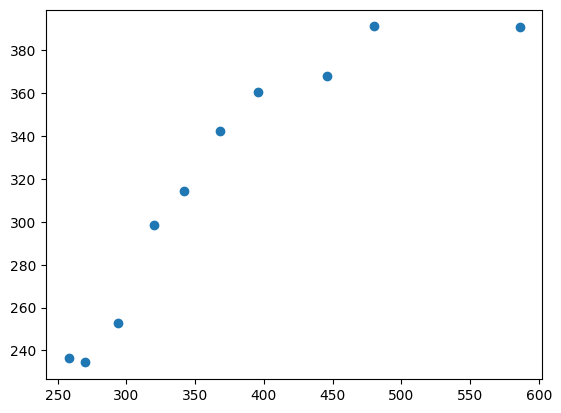

In [5]:
plt.scatter(X, y) 

In [6]:
lr = LinearRegression() # Линейная регрессия
lr.fit(X, y) # Обучим линейную регрессию

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
X_ = np.arange(250, 600, 10)[:, np.newaxis] # Точки для предсказания
y_lr = lr.predict(X_) # Предсказываем y для линейной регрессии

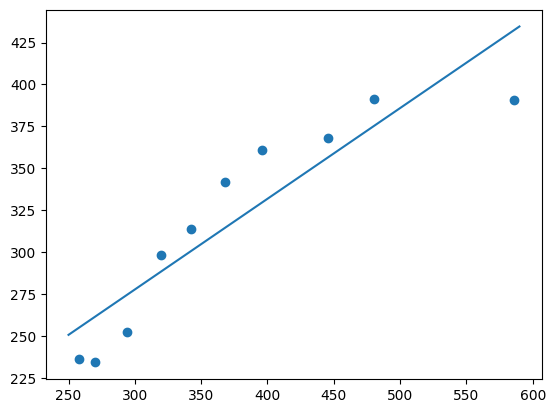

In [8]:
plt.scatter(X, y) 
plt.plot(X_, y_lr) 

In [9]:
pr = LinearRegression() # Полиномиальная регрессия

In [10]:
quadratic = PolynomialFeatures(degree=2)
X_quad = quadratic.fit_transform(X)       # Преобразуем данные

In [10]:
X_quad

array([[1.00000e+00, 2.58000e+02, 6.65640e+04],
       [1.00000e+00, 2.70000e+02, 7.29000e+04],
       [1.00000e+00, 2.94000e+02, 8.64360e+04],
       [1.00000e+00, 3.20000e+02, 1.02400e+05],
       [1.00000e+00, 3.42000e+02, 1.16964e+05],
       [1.00000e+00, 3.68000e+02, 1.35424e+05],
       [1.00000e+00, 3.96000e+02, 1.56816e+05],
       [1.00000e+00, 4.46000e+02, 1.98916e+05],
       [1.00000e+00, 4.80000e+02, 2.30400e+05],
       [1.00000e+00, 5.86000e+02, 3.43396e+05]])

In [12]:
pr.fit(X_quad, y) # Обучаем полиномиальную регрессию

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pr = pr.predict(quadratic.fit_transform(X_)) # Предсказываем y для полиномиальной регрессии

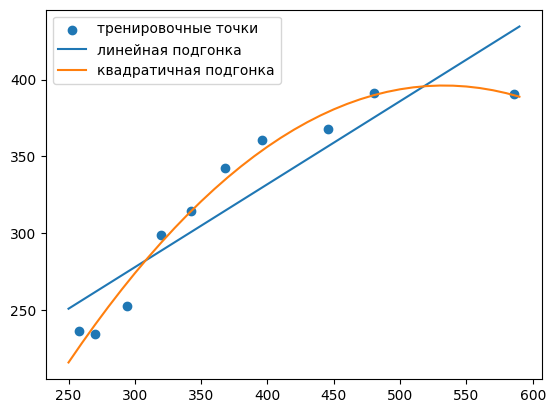

In [14]:
plt.scatter(X, y, label = 'тренировочные точки') 
plt.plot(X_, y_lr, label = 'линейная подгонка') 
plt.plot(X_, y_pr, label = 'квадратичная подгонка') 
plt.legend(loc='upper left') 
plt.show()

Задание 1. Оцените полученные модели с помощью коэффициента детерминации и MSE. Что можно сказать о качестве моделей?

Замечание!!! mean_squared_error принимает 1-м аргументом истинные значения y, а 2-м предсказанные (см. документацию!). 
Получается, для линейной регрессии:

---

**НАШИ ЯЧЕЙКИ (НЕ КОПИПАСТ):**

In [15]:
from sklearn.metrics import mean_squared_error

# Для наших синих точек 

y_pred_lin = lr.predict(X)
r2_lin = lr.score(X, y)
mse_lin = mean_squared_error(y, y_pred_lin)

print('R2 линейной регрессии:', r2_lin)
print('MSE линейной регрессии:', mse_lin)

# Аналогично выполните для полиномиальной модели и сравните результат

R2 линейной регрессии: 0.8317053837891232
MSE линейной регрессии: 569.7796663183207


In [16]:
# полиномиальная модель
y_pred_poly = pr.predict(X_quad)
r2_poly = pr.score(X_quad, y)
mse_poly = mean_squared_error(y, y_pred_poly)

print('R2 полиномиальной регрессии:', r2_poly)
print('MSE полиномиальной регрессии:', mse_poly)

R2 полиномиальной регрессии: 0.9818850241163604
MSE полиномиальной регрессии: 61.33021451744772


R2 показывает долю дисперсии целевой переменной, объясняемую моделью: чем он ближе к 1, тем лучше модель подгоняется под данные.​

У полиномиальной модели 
R2 почти 0.98, то есть она объясняет около 98% вариации значений 
y, тогда как линейная модель объясняет только около 83%.

MSE — средний квадрат ошибки предсказаний: чем он меньше, тем ближе предсказания к реальным значениям.​

У полиномиальной модели MSE почти в 9 раз меньше (61.3 против 569.8), значит её предсказания в среднем гораздо ближе к наблюдаемым данным, чем у линейной.

---

Задание 2. Постройте полиномиальную модель, описывающую следующую зависимость:

R2: 0.9988415426719927
MSE: 0.10602278058143698


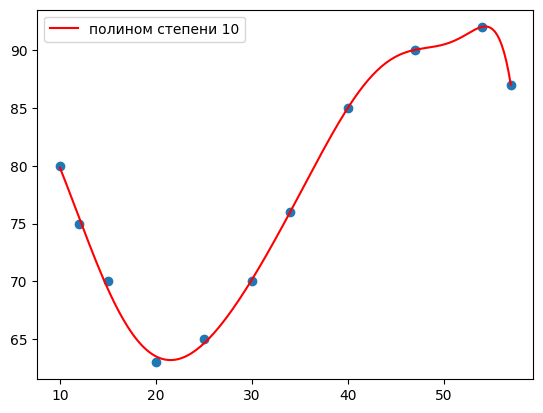

In [17]:
x = np.array([10, 12, 15, 20, 25, 30, 34, 40, 47, 54, 57])[:, np.newaxis]   # БЫЛО
y = np.array([80, 75, 70, 63, 65, 70, 76, 85, 90, 92, 87 ])                 # БЫЛО

degree = 10
poly = PolynomialFeatures(degree=degree)
x_poly = poly.fit_transform(x)

model = LinearRegression()
model.fit(x_poly, y)

y_pred = model.predict(x_poly)
print('R2:', model.score(x_poly, y))
print('MSE:', mean_squared_error(y, y_pred))

# делаем более плотную сетку по X для гладкой линии
x_line = np.linspace(x.min(), x.max(), 200)[:, np.newaxis]
x_line_poly = poly.transform(x_line)
y_line = model.predict(x_line_poly)

plt.scatter(x, y) # Изображаем точки на графике # БЫЛО
plt.plot(x_line, y_line, color='red', label=f'полином степени {degree}')
plt.legend()
plt.show()        # БЫЛО

---

Задание 3. Какую степень полинома вы использовали? Попробуйте изменить степень полинома, например, на 2, 5, 15? Как меняется результат?

degree=2: R2=0.6745, MSE=29.7942


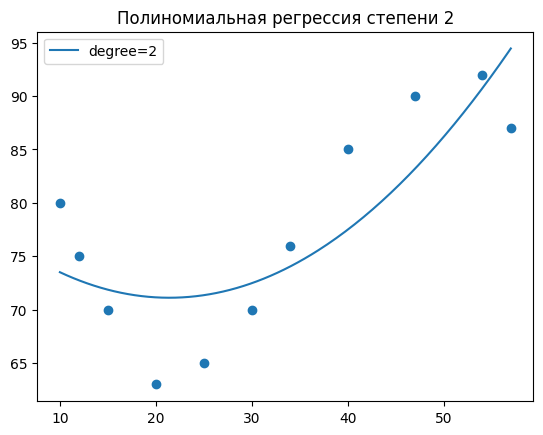

degree=3: R2=0.9926, MSE=0.6786


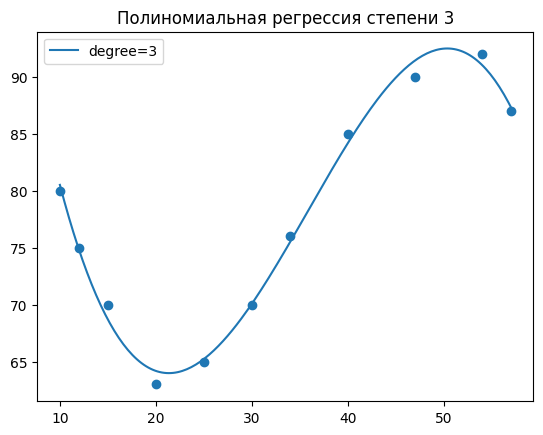

degree=4: R2=0.9926, MSE=0.6771


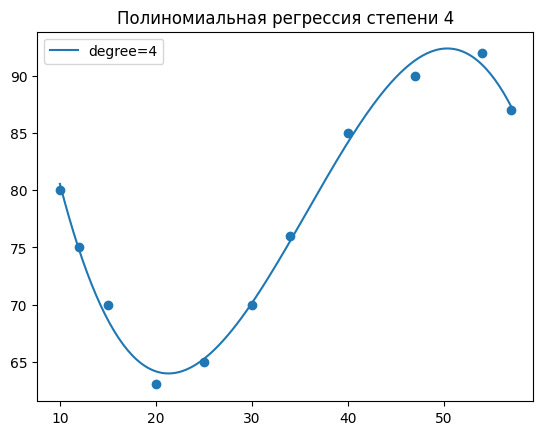

degree=5: R2=0.9932, MSE=0.6219


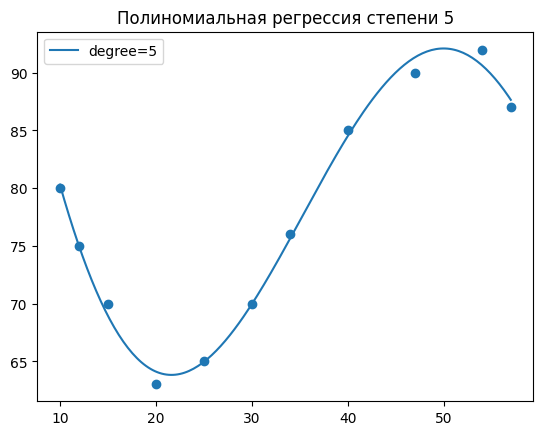

degree=6: R2=0.9974, MSE=0.2336


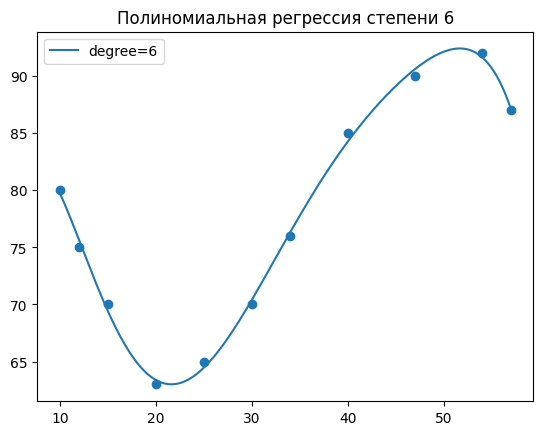

degree=7: R2=0.9982, MSE=0.1656


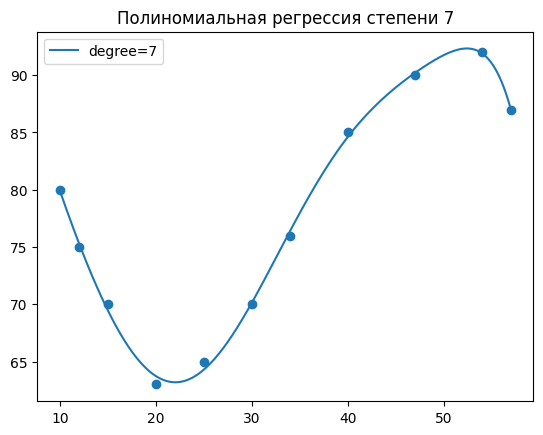

degree=8: R2=0.9983, MSE=0.1570


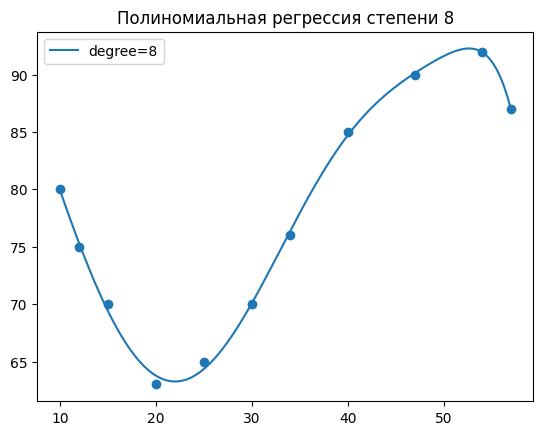

degree=9: R2=0.9985, MSE=0.1400


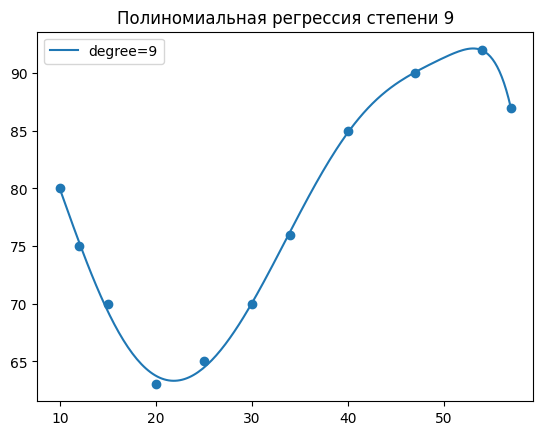

degree=10: R2=0.9988, MSE=0.1060


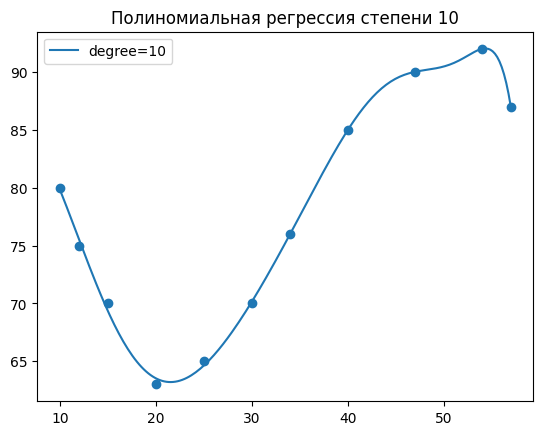

degree=11: R2=0.9716, MSE=2.5997


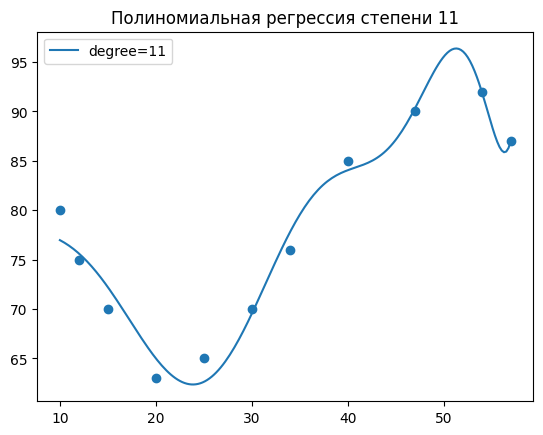

degree=12: R2=0.9494, MSE=4.6349


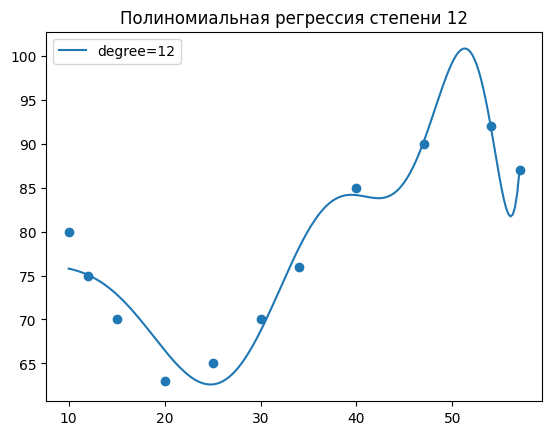

degree=13: R2=0.9245, MSE=6.9132


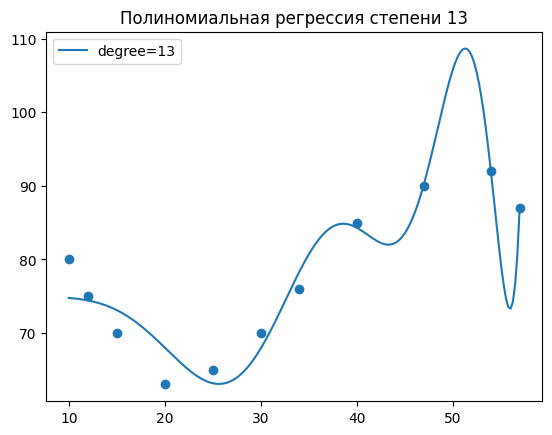

degree=14: R2=0.9001, MSE=9.1422


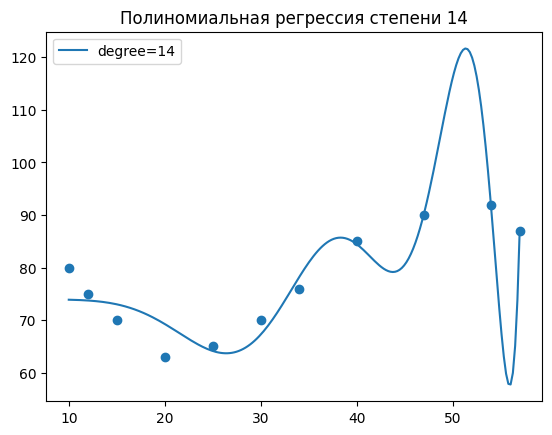

degree=15: R2=0.8784, MSE=11.1297


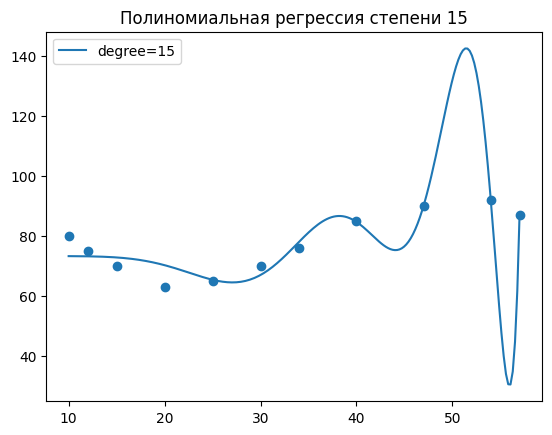

In [18]:
x_line = np.linspace(x.min(), x.max(), 200)[:, np.newaxis]

for degree in range(2, 16):      # степени 2..15 включительно
    poly = PolynomialFeatures(degree=degree)
    x_poly = poly.fit_transform(x)
    x_line_poly = poly.transform(x_line)

    model = LinearRegression()
    model.fit(x_poly, y)

    # предсказания на обучающих точках
    y_pred = model.predict(x_poly)

    # метрики
    r2 = model.score(x_poly, y)                  # коэффициент детерминации
    mse = mean_squared_error(y, y_pred)          # среднеквадратичная ошибка

    print(f'degree={degree}: R2={r2:.4f}, MSE={mse:.4f}')

    # график 
    y_line = model.predict(x_line_poly)
    plt.scatter(x, y)
    plt.plot(x_line, y_line, label=f'degree={degree}')
    plt.title(f'Полиномиальная регрессия степени {degree}')
    plt.legend()
    plt.show()